# Dataset plots

Visualization and threshold tuning for eye gesture event detection.

In [1]:
from pathlib import Path

from src.analyze import analyze_file
from src.blink_signal import has_blink_columns
from src.detection_config import DetectionConfig
from src.gaze_signal import has_gaze_columns
from src.io_utils import collect_csv_files
from src import plots

%reload_ext autoreload
%autoreload 2


DATA_DIR = Path("data")
cfg = DetectionConfig()
files = collect_csv_files(DATA_DIR)
files[:5], len(files)

([PosixPath('data/participant_1_dr_skabek/BlinkData_20260609_112453_10s.csv'),
  PosixPath('data/participant_1_dr_skabek/FixationData_20260609_112242_10s.csv'),
  PosixPath('data/participant_1_dr_skabek/FixationData_20260609_112339_10s.csv'),
  PosixPath('data/participant_1_dr_skabek/SaccadeData_20260609_112413_10s.csv')],
 4)

## Threshold adjustments

In [2]:
cfg = DetectionConfig(
    fixation_speed_threshold_deg_s=30.0,
    saccade_speed_threshold_deg_s=120.0,
    blink_threshold=0.60,
)

In [3]:
sample_path = files[0]
df, events = analyze_file(sample_path, cfg)
sample_path.name, events.head()

('BlinkData_20260609_112453_10s.csv',
                          source_file      phase gesture start_time_s  \
 0  BlinkData_20260609_112453_10s.csv  recording   blink        2.538   
 1  BlinkData_20260609_112453_10s.csv  recording   blink        4.088   
 2  BlinkData_20260609_112453_10s.csv  recording   blink        5.456   
 3  BlinkData_20260609_112453_10s.csv  recording   blink        7.007   
 4  BlinkData_20260609_112453_10s.csv  recording   blink        8.598   
 
   end_time_s duration_ms peak_value sample_count  
 0      3.031       493.0        1.0           45  
 1      4.278       190.0        1.0           18  
 2      5.614       158.0        1.0           15  
 3      7.418       411.0   0.988365           38  
 4      8.967       369.0   0.987465           34  )

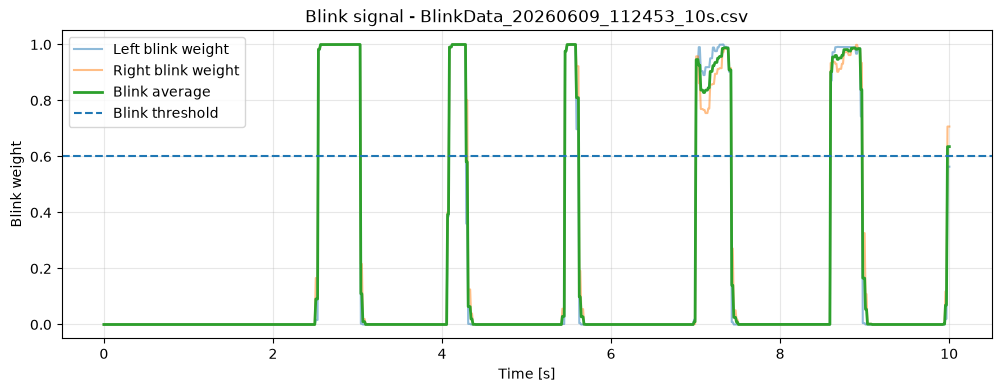

In [4]:
if has_gaze_columns(df):
    plots.plot_gaze_speed(df, cfg)
    plots.plot_smoothed_gaze_speed(df, cfg)
if has_blink_columns(df):
    plots.plot_blink_signal(df, cfg)

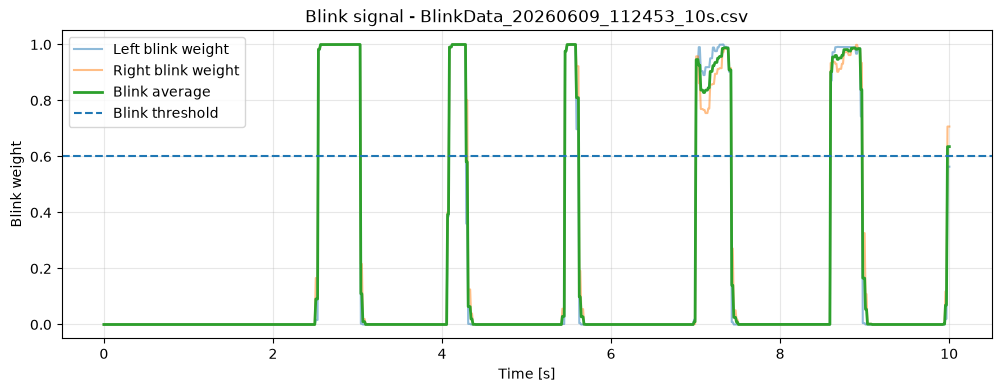

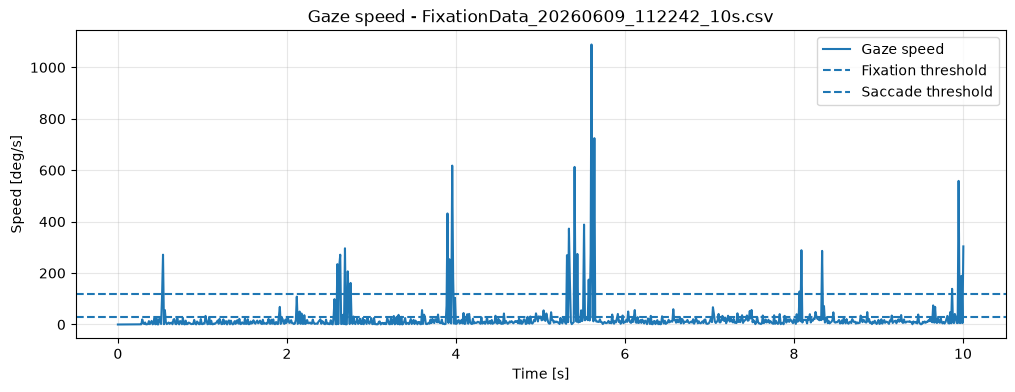

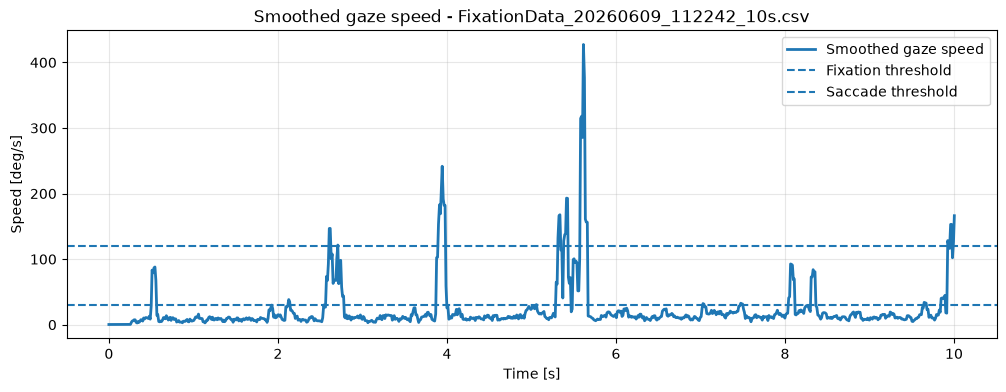

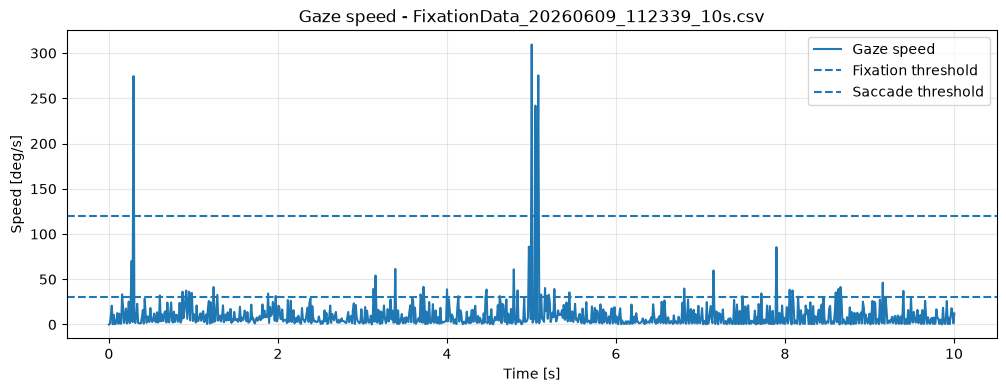

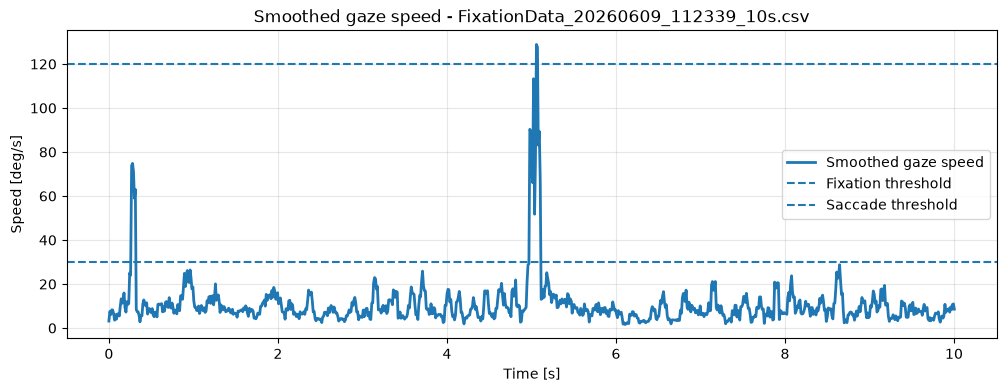

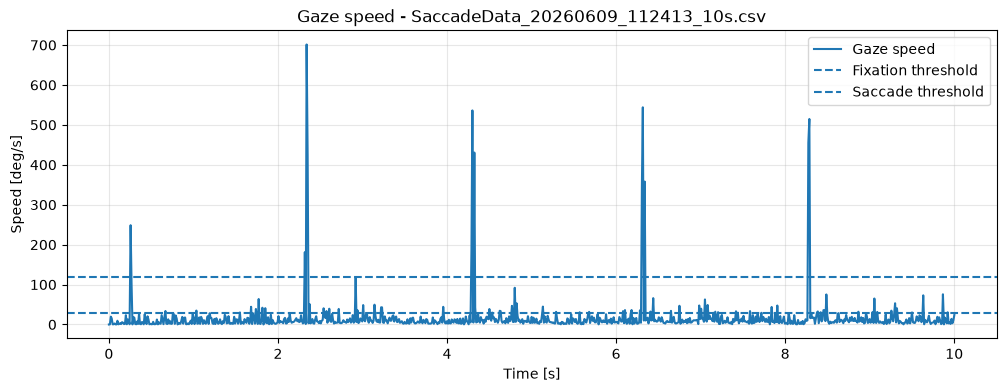

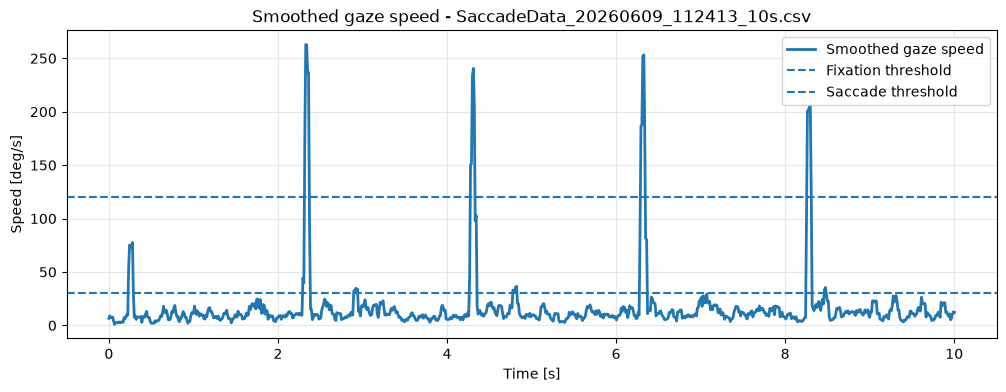

In [5]:
for path in files:
    df, _ = analyze_file(path, cfg)
    if has_gaze_columns(df):
        plots.plot_gaze_speed(df, cfg)
        plots.plot_smoothed_gaze_speed(df, cfg)
    if has_blink_columns(df):
        plots.plot_blink_signal(df, cfg)